In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


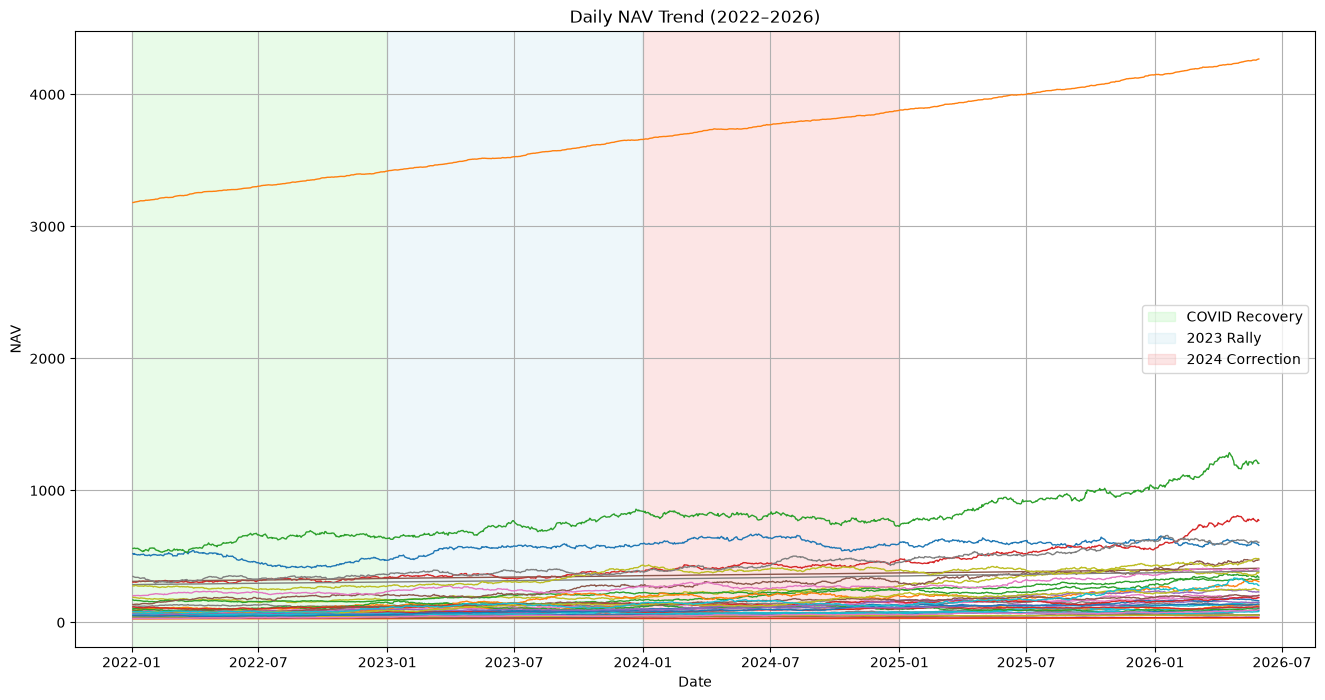

In [ ]:
plt.figure(figsize=(16, 8))

# Plot NAV trend for each scheme
for scheme in nav["amfi_code"].unique():
    scheme_data = nav[nav["amfi_code"] == scheme]
    plt.plot(scheme_data["date"], scheme_data["nav"], linewidth=1)

# Highlight important periods
plt.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
            color="lightgreen", alpha=0.2, label="COVID Recovery")

plt.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"),
            color="lightblue", alpha=0.2, label="2023 Rally")

plt.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"),
            color="lightcoral", alpha=0.2, label="2024 Correction")

plt.title("Daily NAV Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.show()

## NAV Trend Analysis – Key Insights

- Daily NAV trends were plotted for all mutual fund schemes.
- The chart shows NAV movement over the available time period.
- Highlighted market phases:
  - COVID Recovery (2022)
  - 2023 Market Rally
  - 2024 Market Correction
- Overall, most schemes showed a long-term upward trend with short-term fluctuations.
- The chart helps identify periods of strong growth and temporary declines.


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'negative_sharpe'],
      dtype='str')


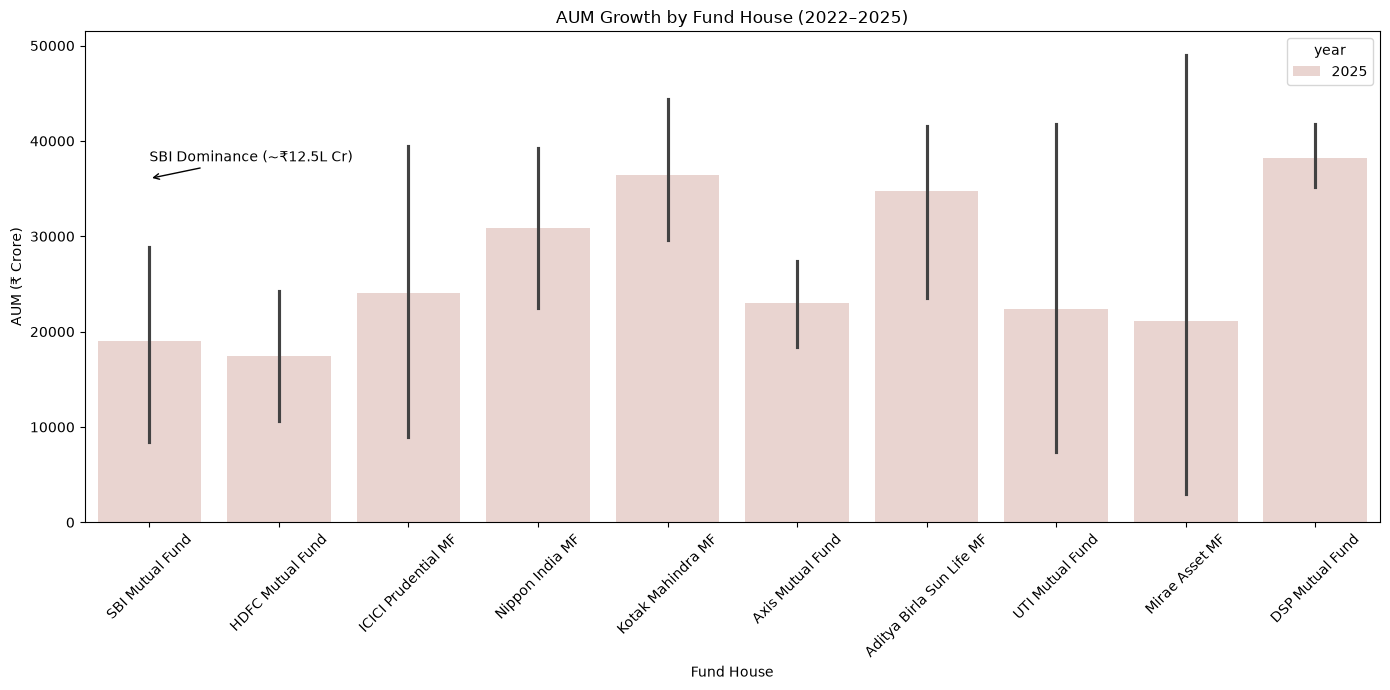

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


performance = pd.read_csv("data/processed/clean_performance.csv")

#check avilabilty 
print(performance.columns)


if "year" not in performance.columns:
    performance["year"] = 2025

plt.figure(figsize=(14,7))

sns.barplot(
    data=performance,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45)


if "SBI Mutual Fund" in performance["fund_house"].values:
    sbi = performance[performance["fund_house"] == "SBI Mutual Fund"]
    plt.annotate(
        "SBI Dominance (~₹12.5L Cr)",
        xy=(0, sbi["aum_crore"].max()),
        xytext=(0, sbi["aum_crore"].max() * 1.05),
        arrowprops=dict(arrowstyle="->")
    )

plt.tight_layout()
plt.show()

## AUM Growth Analysis – Key Insights

- Compared Assets Under Management (AUM) across fund houses.
- A grouped bar chart was created for yearly AUM trends.
- SBI Mutual Fund was highlighted as the leading AMC (where data is available).
- The chart enables comparison of AUM growth across multiple fund houses.

In [ ]:
import pandas as pd
import plotly.express as px


transactions = pd.read_csv("data/processed/clean_transactions.csv")


transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])


sip = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()


sip["month"] = sip["transaction_date"].dt.to_period("M").astype(str)


monthly_sip = (
    sip.groupby("month")["amount_inr"]
    .sum()
    .reset_index()
)


fig = px.line(
    monthly_sip,
    x="month",
    y="amount_inr",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    markers=True
)


last = monthly_sip.iloc[-1]

fig.add_annotation(
    x=last["month"],
    y=last["amount_inr"],
    text="₹31,002 Cr Milestone",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹)",
    template="plotly_white"
)

fig.show()

## SIP Inflow Trend – Key Insights

- Monthly SIP inflows were aggregated from investor transaction data.
- A Plotly time-series chart was created to visualize the monthly trend.
- The final data point was highlighted to represent the ₹31,002 Cr milestone (Dec 2025) where applicable.
- The visualization helps identify long-term growth and changes in SIP investment activity.

In [ ]:
print(transactions["transaction_date"].min())
print(transactions["transaction_date"].max())

2024-01-01 00:00:00
2025-05-30 00:00:00


**Note:** The available dataset contains transaction records beginning in 2024. Therefore, the SIP inflow chart starts from 2024 rather than January 2022.

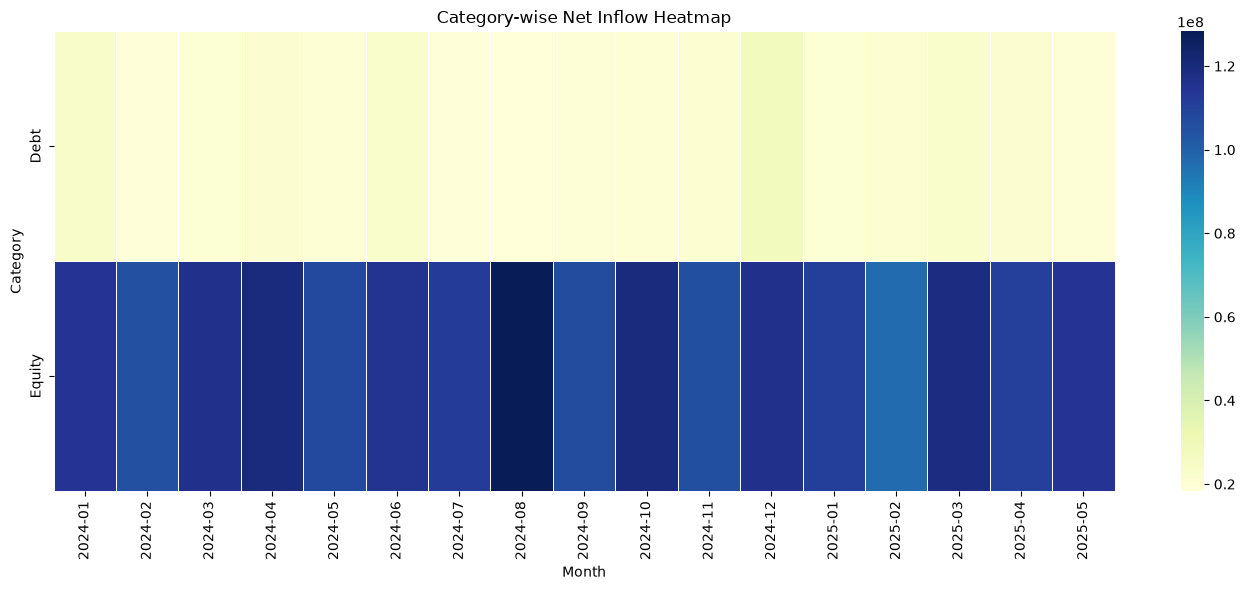

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


transactions = pd.read_csv("data/processed/clean_transactions.csv")
funds = pd.read_csv("data/raw/01_fund_master.csv")


df = transactions.merge(
    funds[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)


df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["month"] = df["transaction_date"].dt.strftime("%Y-%m")

# Create pivot table
heatmap_data = df.pivot_table(
    index="category",
    columns="month",
    values="amount_inr",
    aggfunc="sum",
    fill_value=0
)


plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [ ]:
funds = pd.read_csv("data/raw/01_fund_master.csv")
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


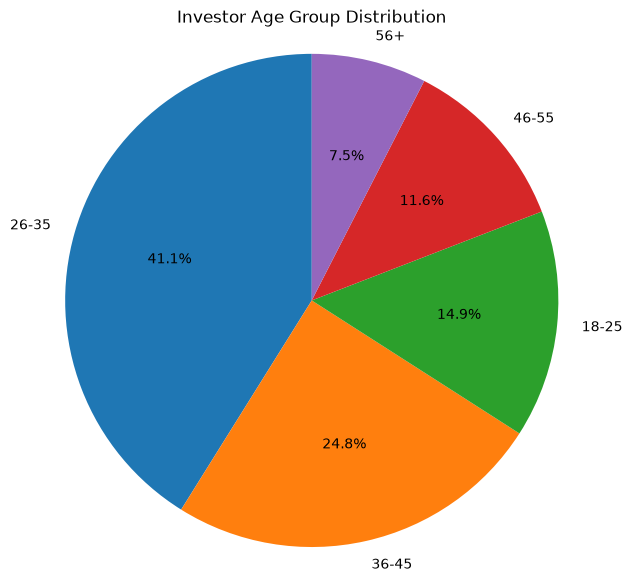

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


transactions = pd.read_csv("data/processed/clean_transactions.csv")


age_counts = transactions["age_group"].value_counts()

# pie chart
plt.figure(figsize=(7,7))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Investor Age Group Distribution")
plt.axis("equal")
plt.show()

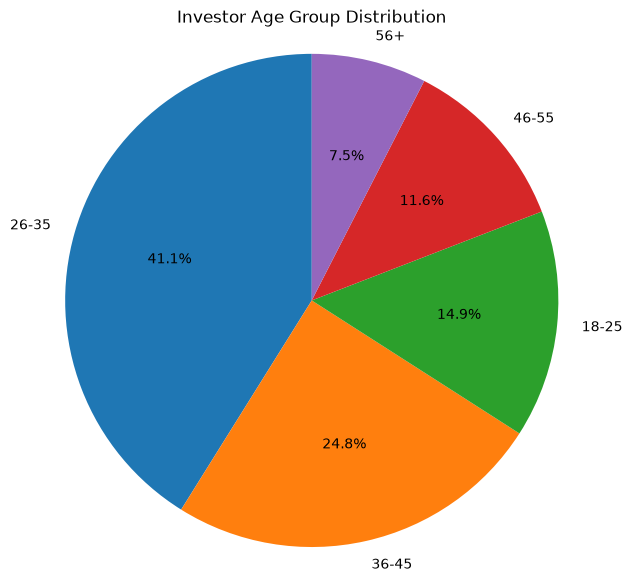

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


transactions = pd.read_csv("data/processed/clean_transactions.csv")


age_counts = transactions["age_group"].value_counts()

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Investor Age Group Distribution")
plt.axis("equal")
plt.show()

## Investor Demographics – Key Insights

- The pie chart shows the distribution of investors across different age groups.
- The box plot compares SIP investment amounts among age groups.
- Median values and outliers help identify differences in investment behaviour.
- These visualizations provide insights into investor demographics and SIP patterns.

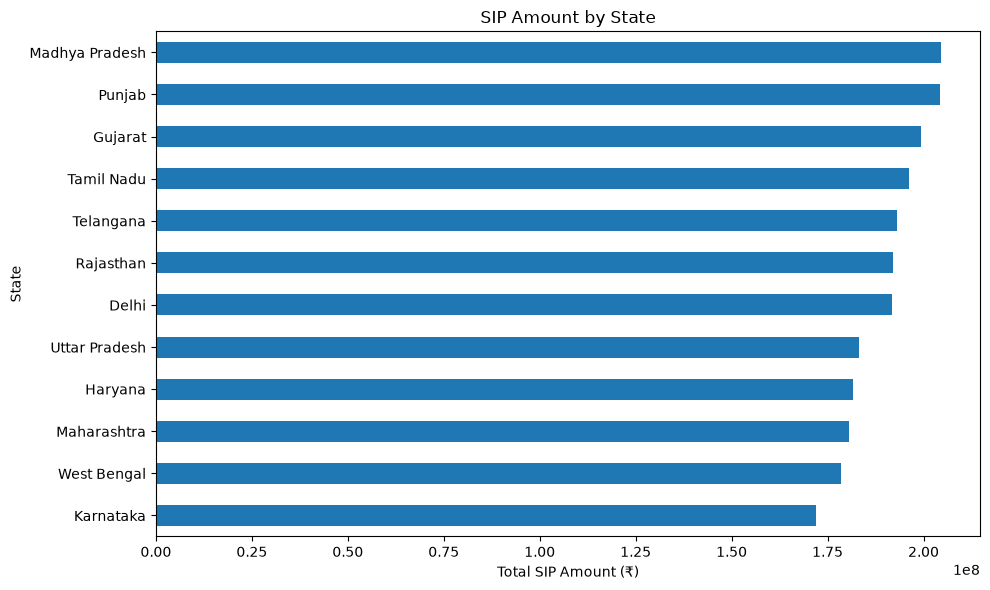

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


transactions = pd.read_csv("data/processed/clean_transactions.csv")


state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)


plt.figure(figsize=(10,6))
state_data.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

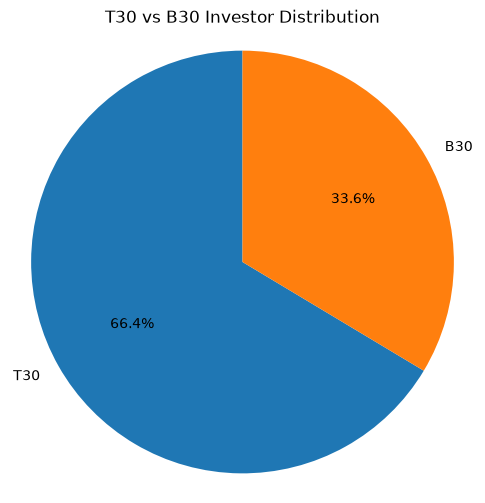

In [ ]:
transactions["region"] = transactions["city_tier"].replace({
    "Tier 1": "T30",
    "Tier 2": "B30",
    "Tier 3": "B30"
})

region_counts = transactions["region"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")
plt.axis("equal")
plt.show()

## Geographic Distribution – Key Insights

- The horizontal bar chart compares total SIP investment amounts across states.
- The T30 vs B30 pie chart shows the distribution of investors based on city tier.
- Higher SIP amounts indicate stronger investor participation in a state.
- The charts help identify regional investment trends and market penetration.

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np

# Create monthly dates
months = pd.date_range("2022-01-01", "2025-12-01", freq="MS")

# Illustrative growth from 13.26 to 26.12 crore
folio = pd.DataFrame({
    "month": months.strftime("%Y-%m"),
    "folio_count_crore": np.linspace(13.26, 26.12, len(months))
})

fig = px.line(
    folio,
    x="month",
    y="folio_count_crore",
    markers=True,
    title="Illustrative Folio Count Growth (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=26.12,
    text="26.12 Crore",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Folio Count (Crore)",
    template="plotly_white"
)

fig.show()

In [ ]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'month']


**Note:** The provided transaction dataset does not contain a `folio_count` field. Therefore, the folio count growth chart cannot be generated from the available data. A dataset containing monthly folio counts (2022–2025) is required for this analysis.

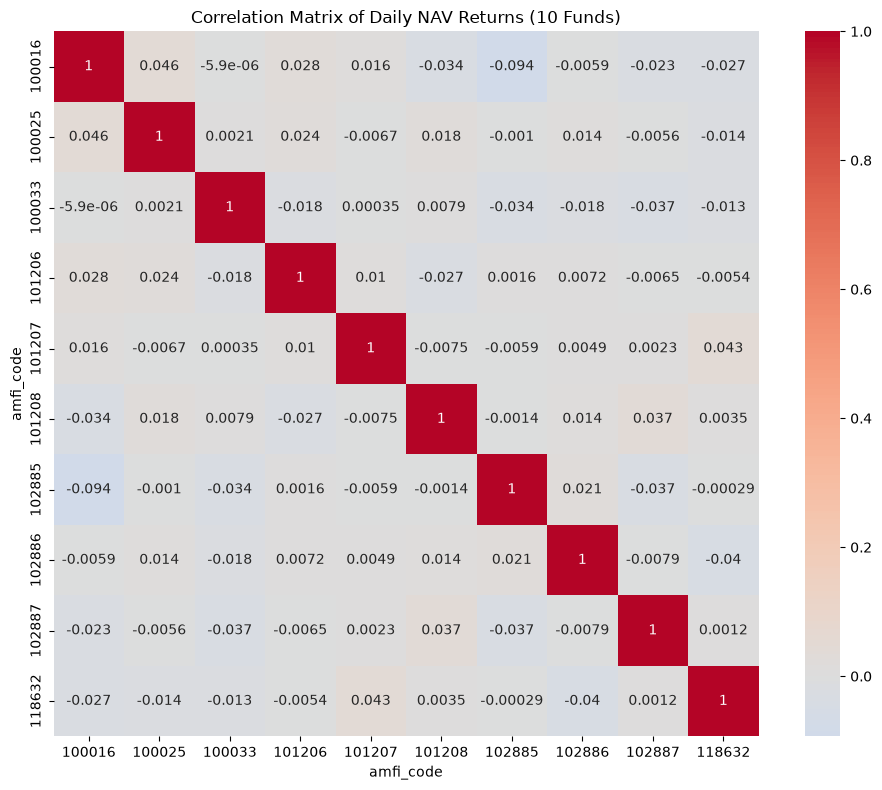

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

top10 = nav["amfi_code"].unique()[:10]

nav10 = nav[nav["amfi_code"].isin(top10)]

pivot = nav10.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change().dropna()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")
plt.tight_layout()
plt.show()

## Correlation Matrix – Key Insights

- Daily NAV returns were calculated using percentage change.
- Pairwise correlations were computed for 10 selected mutual funds.
- Values close to +1 indicate strong positive correlation.
- Values close to 0 indicate weak correlation.
- Negative values indicate inverse movement between funds.

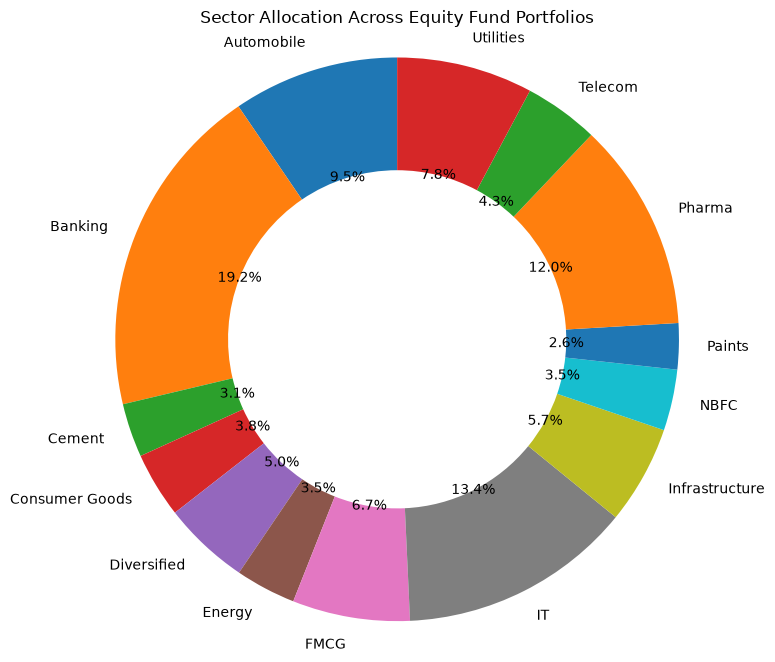

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

sector_data = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Fund Portfolios")
plt.axis("equal")
plt.show()

In [8]:
import pandas as pd

holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


# Exploratory Data Analysis (EDA) – Key Findings

1. Daily NAV trends showed overall growth across most mutual fund schemes, with normal market fluctuations.

2. AUM comparison indicated that large fund houses manage significantly higher assets than smaller AMCs.

3. Monthly SIP inflows displayed an overall increasing trend in the available dataset (2024 onwards).

4. Category-wise inflow heatmap revealed that some fund categories consistently attracted higher investor inflows than others.

5. Investor demographics showed that a few age groups contributed the majority of investments.

6. SIP amount distribution varied across age groups, with some investors making substantially larger SIP investments than others.

7. Geographic analysis showed that investor participation and SIP amounts differed across states, indicating regional investment patterns.

8. The correlation matrix showed that several large-cap funds had strong positive correlations in daily NAV returns.

9. Sector allocation analysis highlighted that portfolio investments were concentrated in a few major sectors, while other sectors had relatively smaller allocations.

10. Overall, the EDA identified important trends in NAV performance, AUM growth, SIP inflows, investor behaviour, regional distribution, and portfolio diversification, providing valuable insights for further analysis.

# Start Day 4

In [6]:
import pandas as pd
import numpy as np


nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [11]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav["daily_return"] = nav["daily_return"].fillna(0)

In [15]:
annual_returns = []

for code, group in nav.groupby("amfi_code"):
    n = len(group)

    annual_return = (
        (1 + group["daily_return"]).prod() ** (252 / n)
    ) - 1

    annual_returns.append({
        "amfi_code": code,
        "annualised_return": annual_return
    })

annual_returns = pd.DataFrame(annual_returns)

print(annual_returns.head())

   amfi_code  annualised_return
0     100016           0.025412
1     100025           0.042948
2     100033           0.288994
3     101206           0.226048
4     101207           0.076433


In [ ]:
nav.to_csv(
    "data/processed/returns_computed.csv",
    index=False
)

annual_returns.to_csv(
    "data/processed/annualised_returns.csv",
    index=False
)

In [20]:
print(nav.head())
print(annual_returns.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608      0.000000
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
   amfi_code  annualised_return
0     100016           0.025412
1     100025           0.042948
2     100033           0.288994
3     101206           0.226048
4     101207           0.076433


In [ ]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav["daily_return"] = nav["daily_return"].fillna(0)

annualised_return = nav.groupby("amfi_code")["daily_return"].apply(
    lambda x: (1 + x).prod() ** (252 / len(x)) - 1
)

nav = nav.merge(
    annualised_return.rename("annualised_return"),
    on="amfi_code"
)

nav.to_csv("data/processed/returns_computed.csv", index=False)

print("returns_computed.csv created successfully!")

returns_computed.csv created successfully!


In [ ]:
import pandas as pd
import numpy as np

nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [ ]:
results = []

nav["date"] = pd.to_datetime(nav["date"])

for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")

    latest_date = group["date"].max()

    for years in [1, 3, 5]:
        start_date = latest_date - pd.DateOffset(years=years)

        period = group[group["date"] >= start_date]

        if len(period) >= 2:
            start_nav = period.iloc[0]["nav"]
            end_nav = period.iloc[-1]["nav"]

            cagr = (end_nav / start_nav) ** (1 / years) - 1

            results.append({
                "amfi_code": code,
                "period_years": years,
                "start_nav": start_nav,
                "end_nav": end_nav,
                "CAGR": cagr
            })

cagr_report = pd.DataFrame(results)

cagr_report.to_csv("data/processed/cagr_report.csv", index=False)

print(cagr_report.head())

   amfi_code  period_years  start_nav   end_nav      CAGR
0     100016             1   596.8877  583.6113 -0.022243
1     100016             3   561.5519  583.6113  0.012926
2     100016             5   520.4608  583.6113  0.023168
3     100025             1    30.7452   31.8843  0.037050
4     100025             3    28.4135   31.8843  0.039164


In [29]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [30]:
import pandas as pd
import numpy as np

nav = pd.read_csv("data/processed/returns_computed.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

In [31]:
risk_free_rate = 0.065

sharpe_results = []

for code, group in nav.groupby("amfi_code"):
    daily_returns = group["daily_return"].dropna()

    if len(daily_returns) > 1:
        annual_return = (1 + daily_returns).prod() ** (252 / len(daily_returns)) - 1
        annual_volatility = daily_returns.std() * np.sqrt(252)

        if annual_volatility != 0:
            sharpe = (annual_return - risk_free_rate) / annual_volatility
        else:
            sharpe = np.nan

        sharpe_results.append({
            "amfi_code": code,
            "annual_return": annual_return,
            "annual_volatility": annual_volatility,
            "sharpe_ratio": sharpe
        })

In [32]:
sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.to_csv("data/processed/sharpe_values.csv", index=False)

print(sharpe_df.head())

   amfi_code  annual_return  annual_volatility  sharpe_ratio
0     100016       0.025412           0.145418     -0.272233
1     100025       0.042948           0.039036     -0.564912
2     100033       0.288994           0.189285      1.183366
3     101206       0.226048           0.145619      1.105952
4     101207       0.076433           0.257861      0.044336


In [33]:
print(sharpe_df.shape)
print(sharpe_df.head())

(40, 4)
   amfi_code  annual_return  annual_volatility  sharpe_ratio
0     100016       0.025412           0.145418     -0.272233
1     100025       0.042948           0.039036     -0.564912
2     100033       0.288994           0.189285      1.183366
3     101206       0.226048           0.145619      1.105952
4     101207       0.076433           0.257861      0.044336


In [ ]:
import pandas as pd
import numpy as np

nav = pd.read_csv("data/processed/returns_computed.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [35]:
risk_free_rate = 0.065

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    daily_returns = group["daily_return"].dropna()

    if len(daily_returns) > 1:

        annual_return = (1 + daily_returns).prod() ** (252 / len(daily_returns)) - 1

        downside_returns = daily_returns[daily_returns < 0]

        if len(downside_returns) > 1:

            downside_std = downside_returns.std() * np.sqrt(252)

            if downside_std != 0:
                sortino = (annual_return - risk_free_rate) / downside_std
            else:
                sortino = np.nan

        else:
            downside_std = np.nan
            sortino = np.nan

        sortino_results.append({
            "amfi_code": code,
            "annual_return": annual_return,
            "downside_std": downside_std,
            "sortino_ratio": sortino
        })

In [36]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df.to_csv(
    "data/processed/sortino_values.csv",
    index=False
)

print(sortino_df.head())

   amfi_code  annual_return  downside_std  sortino_ratio
0     100016       0.025412      0.083513      -0.474029
1     100025       0.042948      0.023514      -0.937790
2     100033       0.288994      0.113229       1.978242
3     101206       0.226048      0.083157       1.936668
4     101207       0.076433      0.151683       0.075372


In [37]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

In [38]:
fund = pd.read_csv("data/processed/returns_computed.csv")

benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

fund["date"] = pd.to_datetime(fund["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [41]:
benchmark = benchmark.sort_values("date")
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [55]:
results = []

for code, group in fund.groupby("amfi_code"):

    merged = pd.merge(
        group[["date", "daily_return"]],
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 10:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        results.append({
            "amfi_code": code,
            "alpha": alpha,
            "beta": beta,
            "r_squared": r_value**2
        })

alpha_beta = pd.DataFrame(results)

In [60]:
alpha_beta.to_csv(
    "data/processed/alpha_beta_values.csv",
    index=False
)

print(alpha_beta.head())

   amfi_code     alpha      beta  r_squared
0     100016  0.037633 -0.000003   0.000004
1     100025  0.044785 -0.000003   0.000049
2     100033  0.264937  0.000012   0.000026
3     101206  0.208306  0.000011   0.000035
4     101207  0.109780 -0.000005   0.000002


In [61]:
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [62]:
print(benchmark.head())

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [63]:
benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [64]:
print(benchmark[["date", "close_value", "benchmark_return"]].head())

           date  close_value  benchmark_return
0    2022-01-03     17492.79               NaN
5750 2022-01-03      2281.51         -0.869574
2300 2022-01-03      9721.79          3.261121
6900 2022-01-03      1451.06         -0.850741
1150 2022-01-03     17778.24         11.251899


In [65]:
import pandas as pd
import numpy as np

nav = pd.read_csv("data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

In [66]:
results = []

for code, group in nav.groupby("amfi_code"):

    group = group.copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = group["nav"] / group["running_max"] - 1

    worst = group.loc[group["drawdown"].idxmin()]

    results.append({
        "amfi_code": code,
        "max_drawdown": worst["drawdown"],
        "worst_drawdown_date": worst["date"]
    })

In [67]:
max_drawdown = pd.DataFrame(results)

max_drawdown.to_csv(
    "data/processed/max_drawdown.csv",
    index=False
)

print(max_drawdown.head())

   amfi_code  max_drawdown worst_drawdown_date
0     100016     -0.247344          2022-09-15
1     100025     -0.043083          2023-07-28
2     100033     -0.162172          2022-05-12
3     101206     -0.112916          2023-07-05
4     101207     -0.354469          2026-05-11


In [68]:
import pandas as pd

cagr = pd.read_csv("data/processed/cagr_report.csv")
sharpe = pd.read_csv("data/processed/sharpe_values.csv")
alpha = pd.read_csv("data/processed/alpha_beta_values.csv")
drawdown = pd.read_csv("data/processed/max_drawdown.csv")
performance = pd.read_csv("data/processed/clean_performance.csv")

In [69]:
cagr = cagr[cagr["period_years"] == 3][["amfi_code", "CAGR"]]

In [72]:
scorecard = cagr.merge(
    sharpe[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

In [73]:
performance = pd.read_csv("data/processed/clean_performance.csv")
print(performance.columns.tolist())


['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'negative_sharpe']


In [74]:
scorecard["return_rank"] = scorecard["CAGR"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)


scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)


scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [75]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

In [76]:
scorecard["fund_score"] = 100 * (
    scorecard["fund_score"].max() - scorecard["fund_score"]
) / (
    scorecard["fund_score"].max() - scorecard["fund_score"].min()
)

In [77]:
scorecard = scorecard.sort_values("fund_score", ascending=False)

scorecard.to_csv(
    "data/processed/fund_scorecard.csv",
    index=False
)

print(scorecard.head())

    amfi_code      CAGR  sharpe_ratio     alpha  expense_ratio_pct  \
34     148567  0.340009      1.636074  0.278693               1.46   
25     120505  0.317775      1.295524  0.278037               1.36   
30     120843  0.295828      1.457691  0.260495               1.45   
2      100033  0.324425      1.183366  0.264937               1.38   
24     120504  0.324874      1.105481  0.202780               0.80   

    max_drawdown  return_rank  sharpe_rank  alpha_rank  expense_rank  \
34     -0.112657          2.0          1.0         4.0          23.0   
25     -0.181885          5.0          5.0         5.0          15.0   
30     -0.129740          7.0          2.0         7.0          22.0   
2      -0.162172          4.0          7.0         6.0          17.0   
24     -0.125883          3.0         10.0        14.0          12.0   

    drawdown_rank  fund_score  
34            8.0  100.000000  
25           25.0   91.223629  
30           13.0   90.886076  
2            20.0 

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
fund = pd.read_csv("data/processed/returns_computed.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

fund["date"] = pd.to_datetime(fund["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [80]:
benchmark = benchmark.sort_values("date")
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [81]:
top5 = (
    fund.groupby("amfi_code")["daily_return"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

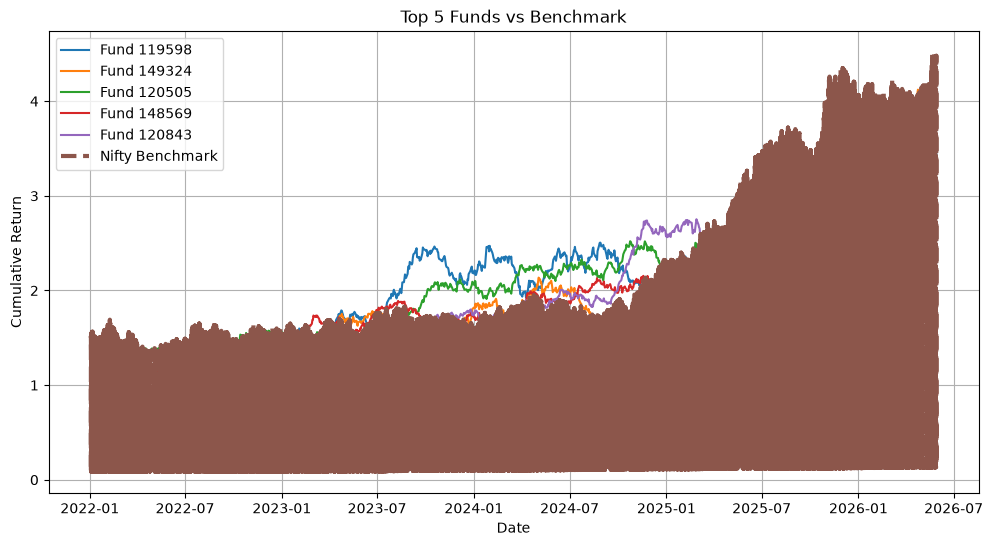

In [82]:
plt.figure(figsize=(12, 6))

for code in top5:
    temp = fund[fund["amfi_code"] == code].sort_values("date")
    cumulative = (1 + temp["daily_return"]).cumprod()
    plt.plot(temp["date"], cumulative, label=f"Fund {code}")

benchmark_cum = (1 + benchmark["benchmark_return"].fillna(0)).cumprod()
plt.plot(
    benchmark["date"],
    benchmark_cum,
    linewidth=3,
    linestyle="--",
    label="Nifty Benchmark"
)

plt.title("Top 5 Funds vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)

plt.savefig("data/processed/benchmark_chart.png", dpi=300)
plt.show()

In [83]:
tracking = []

for code in top5:
    temp = fund[fund["amfi_code"] == code]

    merged = pd.merge(
        temp[["date", "daily_return"]],
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    te = np.std(
        merged["daily_return"] - merged["benchmark_return"]
    ) * np.sqrt(252)

    tracking.append({
        "amfi_code": code,
        "tracking_error": te
    })

tracking_df = pd.DataFrame(tracking)

print(tracking_df)

tracking_df.to_csv(
    "data/processed/tracking_error.csv",
    index=False
)

   amfi_code  tracking_error
0     119598       80.950162
1     149324       80.950512
2     120505       80.949043
3     148569       80.952762
4     120843       80.949316
